In [4]:
# 1. CONFIGURATION

from pathlib import Path

BASE_DIR = Path("../data/kaggle_3m/")

print("Searching for images and masks...")
mask_paths = list(BASE_DIR.rglob("*mask*.*"))
image_paths = [Path(str(m).replace("_mask", "")) for m in mask_paths]

print(f"Found {len(mask_paths)} pairs of picture-mask.")

Searching for images and masks...
Found 3929 pairs of picture-mask.


In [5]:
# 2. DATA PREPROCESSING FUNCTIONS

import cv2
import numpy as np

IMG_SIZE = 128

#Loads a color MRI image, converts to RGB, resizes, and normalizes
def process_image(path):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE)) / 255.0
    return img

#Loads a grayscale tumor mask, resizes, and normalizes
def process_mask(path):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, (IMG_SIZE, IMG_SIZE)) / 255.0
    return mask

# Load data into NumPy arrays
print("Processing dataset into arrays...")
X = np.array([process_image(p) for p in image_paths], dtype=np.float32)
Y = np.array([process_mask(p) for p in mask_paths], dtype=np.float32)

# Add a channel dimension to masks so shape matches (Batch, Height, Width, Channels)
Y = Y[..., np.newaxis]

print(f"Processed X shape (Images): {X.shape}")
print(f"Processed Y shape (Masks): {Y.shape}")

Processing dataset into arrays...
Processed X shape (Images): (3929, 128, 128, 3)
Processed Y shape (Masks): (3929, 128, 128, 1)


In [6]:
# 3. BUILD FULL U-NET MODEL

import keras
from keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, concatenate
from keras.models import Model

def build_full_unet(input_shape=(128, 128, 3)):
    inputs = Input(input_shape)

    # --- ENCODER (Downsampling) ---
    # Level 1
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(32, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1) # 128 -> 64

    # Level 2
    c2 = Conv2D(64, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(64, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2) # 64 -> 32

    # Level 3
    c3 = Conv2D(128, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(128, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3) # 32 -> 16

    # --- BOTTLENECK (Deepest Point) ---
    bn = Conv2D(256, (3, 3), activation='relu', padding='same')(p3)
    bn = Conv2D(256, (3, 3), activation='relu', padding='same')(bn)

    # --- DECODER (Upsampling & Skip Connection) ---
    # Level 3 
    u3 = UpSampling2D((2, 2))(bn) # 16 -> 32
    u3 = concatenate([u3, c3])
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(u3)
    c4 = Conv2D(128, (3, 3), activation='relu', padding='same')(c4)

    # Level 2 
    u2 = UpSampling2D((2, 2))(c4) # 32 -> 64
    u2 = concatenate([u2, c2])
    c5 = Conv2D(64, (3, 3), activation='relu', padding='same')(u2)
    c5 = Conv2D(64, (3, 3), activation='relu', padding='same')(c5)

    # Level 1
    u1 = UpSampling2D((2, 2))(c5) # 64 -> 128
    u1 = concatenate([u1, c1])
    c6 = Conv2D(32, (3, 3), activation='relu', padding='same')(u1)
    c6 = Conv2D(32, (3, 3), activation='relu', padding='same')(c6)

    # --- OUTPUT LAYER ---
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c6)

    return Model(inputs=inputs, outputs=outputs)

model = build_full_unet(input_shape=(IMG_SIZE, IMG_SIZE, 3))


I0000 00:00:1789670313.378232   55638 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789670313.378609   55638 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1789670313.399876   55638 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1789670314.249902   55638 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [7]:
# 4. BUILD CUSTOM LOSS FUNCTION (BCE + DICE LOSS)

import tensorflow as tf

#Calculates the Dice overlap score between true mask and prediction
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    # Flatten the tensors to 1D vectors
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])
    
    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    
    # 2 * intersection divided by the sum of all elements + a tiny smooth factor to avoid division by zero
    res = (2. * intersection + smooth) / (tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + smooth)
    
    return res

#Dice Loss is 1 minus the Dice Coefficient
def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)

#Combines Binary Cross-Entropy and Dice Loss
def bce_dice_loss(y_true, y_pred):
    bce = keras.losses.binary_crossentropy(y_true, y_pred)
    dice = dice_loss(y_true, y_pred)
    
    return bce + dice

In [8]:
# 5. COMPILE & TRAIN

from tensorflow.keras.preprocessing.image import ImageDataGenerator

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4), # Smoother starting speed
    loss=bce_dice_loss,
    metrics=['accuracy', dice_coefficient]
)

print("Full U-Net built successfully! Ready to train.")

# Set up Callbacks (Early Stopping & Learning Rate Scheduler)
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss', 
        patience=5,             # Stop if validation loss doesn't improve for 5 epochs
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5,             # Cut learning rate in half when stuck
        patience=2,             # Wait 2 epochs before cutting
        min_lr=1e-6, 
        verbose=1
    )
]

# Split X and Y into training and validation sets first
val_size = int(len(X) * 0.2)
X_train = X[:-val_size]
Y_train = Y[:-val_size]
X_val = X[-val_size:]
Y_val = Y[-val_size:]

#Data Augmentation
data_gen_args = dict(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)

# Provide the same seed to keep images and masks aligned during augmentation
seed = 666
image_generator = image_datagen.flow(X_train, batch_size=16, seed=seed)
mask_generator = mask_datagen.flow(Y_train, batch_size=16, seed=seed)
train_generator = zip(image_generator, mask_generator)


print("Starting model training...")
history = model.fit(
    X, Y, 
    batch_size=16, val_size = int(len(X) * 0.2)
X_val, Y_val = X[-val_size:], Y[-val_size:]

preds = model.predict(X_val)

tumor_indices = []
for i in range(len(Y_val)):
    if np.sum(Y_val[i]) > 0:  
        tumor_indices.append(i)

print(f"Found {len(tumor_indices)} validation images containing tumors out of {len(Y_val)} total.")

sample_indices = tumor_indices[:3]

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, 4 * len(sample_indices)))

if len(sample_indices) == 1:
    axes = np.array([axes])

for row_idx, i in enumerate(sample_indices):
    # Original MRI Image
    axes[row_idx, 0].imshow(X_val[i])
    axes[row_idx, 0].set_title(f"Original MRI (Index {i})")
    axes[row_idx, 0].axis('off')
    
    # Ground Truth Mask 
    axes[row_idx, 1].imshow(Y_val[i].squeeze(), cmap='gray')
    axes[row_idx, 1].set_title("True Mask (Doctor's Note)")
    axes[row_idx, 1].axis('off')
    
    # Model's Prediction
    pred_mask = (preds[i].squeeze() > 0.5).astype(np.float32)
    axes[row_idx, 2].imshow(pred_mask, cmap='gray')
    axes[row_idx, 2].set_title("Model Prediction")
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.show()
    epochs=50, 
    validation_split=0.2, # Uses 20% of data to validate performance
    callbacks=callbacks, 
    verbose=2
)
print("Training complete!")

Full U-Net built successfully! Ready to train.
Starting model training...
Epoch 1/50


E0000 00:00:1789670329.449270   55638 util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


197/197 - 76s - 386ms/step - accuracy: 0.9853 - dice_coefficient: 0.1362 - loss: 0.9774 - val_accuracy: 0.9873 - val_dice_coefficient: 0.2379 - val_loss: 0.8191 - learning_rate: 1.0000e-04
Epoch 2/50
197/197 - 75s - 379ms/step - accuracy: 0.9899 - dice_coefficient: 0.4772 - loss: 0.5659 - val_accuracy: 0.9877 - val_dice_coefficient: 0.4321 - val_loss: 0.6230 - learning_rate: 1.0000e-04
Epoch 3/50
197/197 - 84s - 427ms/step - accuracy: 0.9922 - dice_coefficient: 0.5975 - loss: 0.4394 - val_accuracy: 0.9916 - val_dice_coefficient: 0.4863 - val_loss: 0.5576 - learning_rate: 1.0000e-04
Epoch 4/50
197/197 - 88s - 447ms/step - accuracy: 0.9929 - dice_coefficient: 0.6265 - loss: 0.4070 - val_accuracy: 0.9922 - val_dice_coefficient: 0.4592 - val_loss: 0.5870 - learning_rate: 1.0000e-04
Epoch 5/50
197/197 - 84s - 425ms/step - accuracy: 0.9934 - dice_coefficient: 0.6601 - loss: 0.3719 - val_accuracy: 0.9914 - val_dice_coefficient: 0.4935 - val_loss: 0.5502 - learning_rate: 1.0000e-04
Epoch 6/50


Generating predictions for visualization...
25/25 ━━━━━━━━━━━━━━━━━━━━ 6s 228ms/step
Found 302 validation images containing tumors out of 785 total.


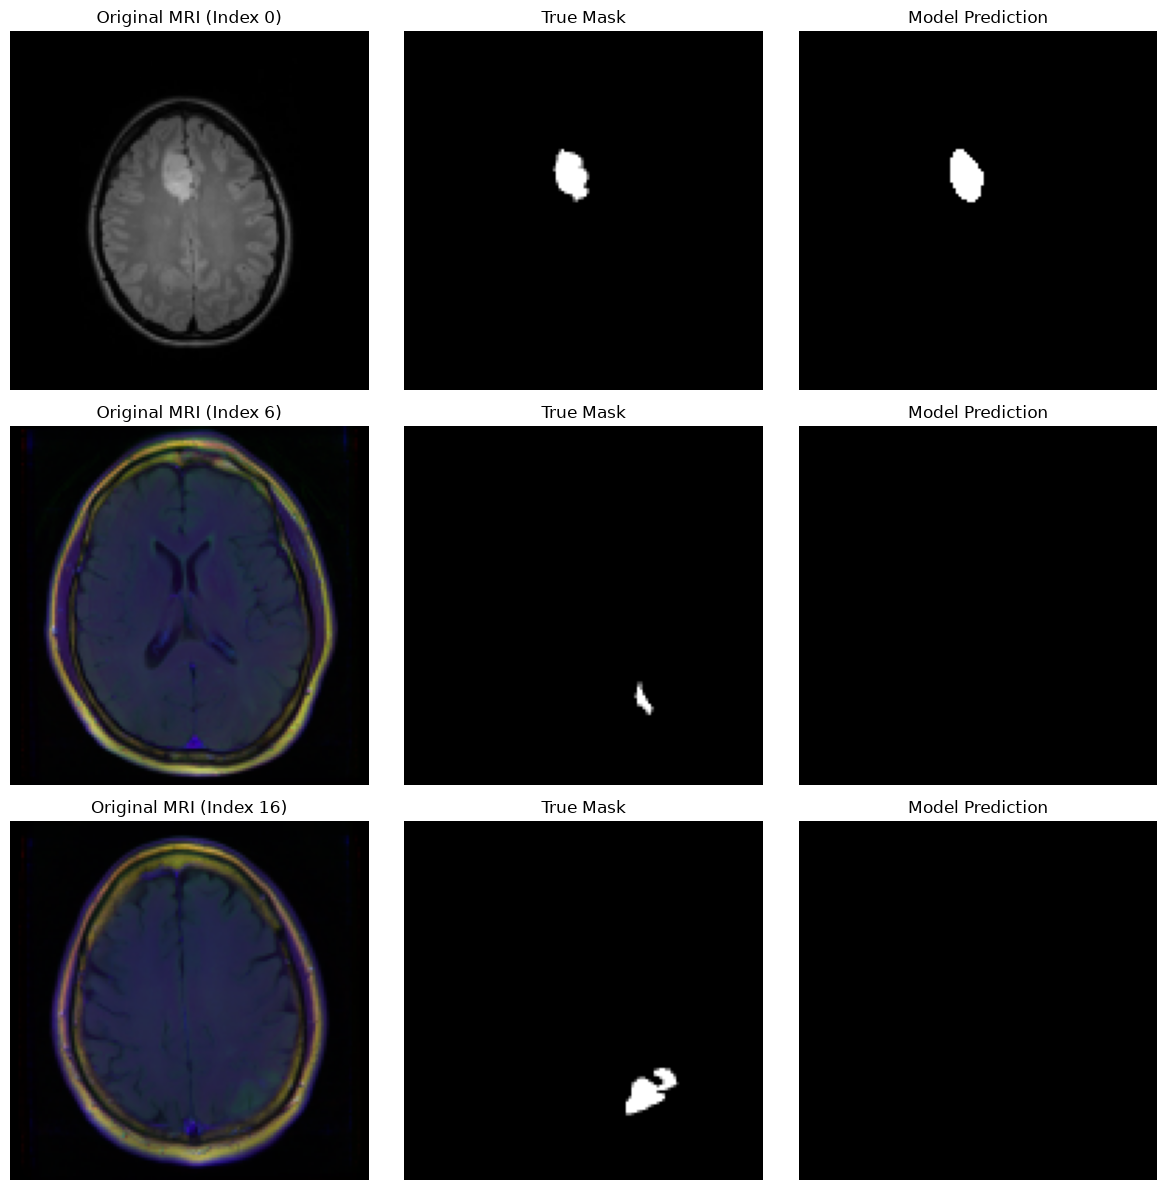

In [11]:
# 6. VISUALIZE THE PREDICTIONS

import matplotlib.pyplot as plt

#Grab a small batch of validation images from your data
val_size = int(len(X) * 0.2)
X_val, Y_val = X[-val_size:], Y[-val_size:]

#Get predictions from your trained model
print("Generating predictions for visualization...")
preds = model.predict(X_val)

tumor_indices = []
for i in range(len(Y_val)):
    if np.sum(Y_val[i]) > 0:  
        tumor_indices.append(i)

print(f"Found {len(tumor_indices)} validation images containing tumors out of {len(Y_val)} total.")

sample_indices = tumor_indices[:3]

fig, axes = plt.subplots(len(sample_indices), 3, figsize=(12, 4 * len(sample_indices)))

if len(sample_indices) == 1:
    axes = np.array([axes])

#Plot a few examples (e.g., first 3 tumor-containing images)
for row_idx, i in enumerate(sample_indices):
    # Original MRI Image
    axes[row_idx, 0].imshow(X_val[i])
    axes[row_idx, 0].set_title(f"Original MRI (Index {i})")
    axes[row_idx, 0].axis('off')
    
    # Ground Truth Mask 
    axes[row_idx, 1].imshow(Y_val[i].squeeze(), cmap='gray')
    axes[row_idx, 1].set_title("True Mask")
    axes[row_idx, 1].axis('off')
    
    # Model's Prediction
    pred_mask = (preds[i].squeeze() > 0.5).astype(np.float32)
    axes[row_idx, 2].imshow(pred_mask, cmap='gray')
    axes[row_idx, 2].set_title("Model Prediction")
    axes[row_idx, 2].axis('off')

plt.tight_layout()
plt.show()